<img src="logo-UNSAM.png" style="float: right;" width="300" alt="Logo">

# <center>Análisis y Procesamiento de Señales</center>
<hr>

## <center>**TS2**: "Modelizando un ADC"</center>

<br><br>

### <center>1er Cuatrimestre - 2026</center>
### <center>**Alumno:** D'Alesio Alejo</center>


<br>

Inicialmente genero una señal senoidal de una frecuencia $ fs = \frac{fm}{N}$, donde $fm$ es la frecuencia de muestreo que será $fm=1000 Hz$ y $N = 1000$ la cantidad de muestras

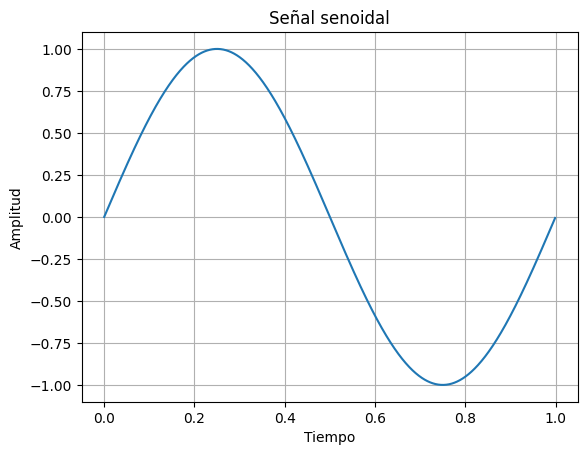

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def mi_funcion_sen(vmax, dc, fs, ph, nn, fm):

    tt = np.arange(nn) / fm 
    s = dc + vmax * np.sin(2 * np.pi * fs * tt + ph)

    return tt, s

vmax = 1
dc = 0
ph = 0
nn = 1000
fm = 1000 
fs = fm/nn #LO CAMBIE , NO ES ARBITRARIO
tt, s = mi_funcion_sen(vmax, dc, fs, ph, nn, fm)

plt.figure()
plt.plot(tt,s, label="señal original")
plt.title("Señal senoidal")
plt.ylabel("Amplitud")
plt.xlabel("Tiempo")
plt.grid()

Luego, a esta señal senoidal (s) le vamos a agregar de manera aditiva una secuencia que simulará una interferencia (n), de manera que nos quedaría una señal con ruido $Sr = n + s$ 

El ruido se modela como un proceso aleatorio gaussiano de media cero, es decir, con distribución normal $\mathcal{N}(0, \sigma^2)$. La varianza $\sigma^2$ del ruido coincide con su potencia $Pn$. Para determinar dicha potencia, se parte de la potencia del ruido de cuantización definido como  $ Pq = \frac{q²}{12}$, donde $q$ es el paso de cuantización $ q = \frac{Vf}{2^B}$, siendo en nuestro caso Vf = 2 y B = 4. Luego, la potencia del ruido se define como una versión escalada de esta $Pn = Kn.Pq$, donde $Kn$ es un factor de escala que permite ajustar el nivel de ruido, en nuestro caso $Kn = 1$. Finalmente, el ruido se genera como una señal gaussiana con varianza $\sigma^2 = Pn$

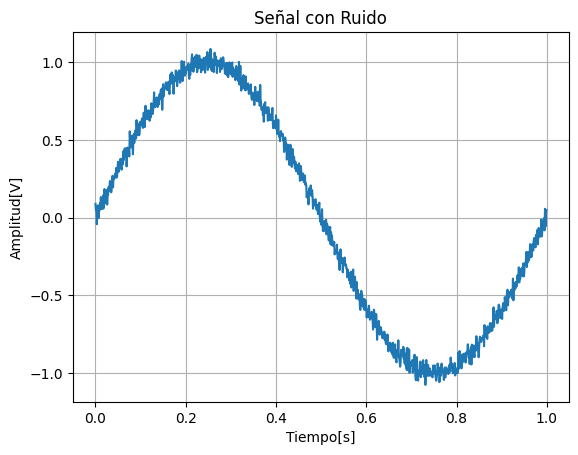

In [8]:
mu = 0
nn = 1000
vmax=1

B = 4
Vfs = 2
q=Vfs/2**B
K_n = 1
Pq = (q**2)/12

Pr_n = K_n*Pq

sigma = np.sqrt(Pr_n) #es la que uso en ruido, sigma² es potencia de ruido

n = np.random.normal(mu, sigma, nn)

señal_con_ruido = s + n


plt.figure()
plt.plot(tt,señal_con_ruido, label = "señal con ruido")
plt.title(label = "Señal con Ruido")
plt.ylabel("Amplitud[V]")
plt.xlabel("Tiempo[s]")
plt.grid()

Para digitalizar una señal analógica, en este caso una señal senoidal, primero consideramos la presencia de ruido aditivo, obteniéndose la señal de entrada al ADC como la suma de la señal original y el ruido. Luego, esta señal es procesada por el conversor ADC, el cual realiza el muestreo y la cuantización. Este último proceso consiste en aproximar la amplitud de la señal a un conjunto finito de niveles, lo que introduce un error conocido como error de cuantización.

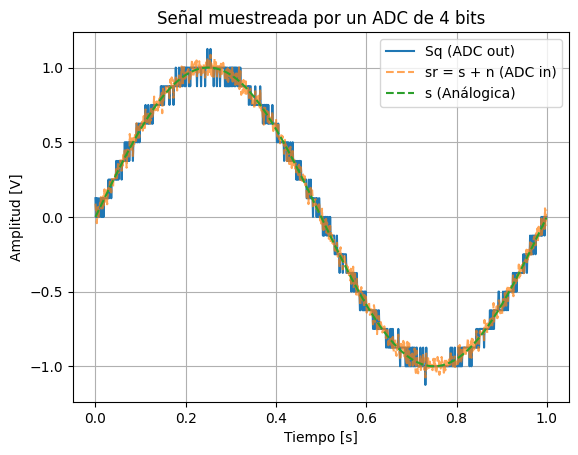

In [9]:
xq = np.round(señal_con_ruido / q)*q
# =========================
# Gráfico final
# =========================
plt.figure()

# ADC out (línea continua)
plt.plot(tt, xq, label='Sq (ADC out)')

# ADC in (solo puntos)
plt.plot(tt, señal_con_ruido, '--', markersize=3, alpha=0.7, label='sr = s + n (ADC in)')

# Señal analógica (línea punteada)
plt.plot(tt, s, '--', label='s (Análogica)')

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal muestreada por un ADC de 4 bits")
plt.legend()
plt.grid()

plt.show()

Para analizar el comportamiento espectral de las señales, grafico la Densidad Espectral de Potencia de cada una. La Densidad Espectral de Potencia indica cómo se distribuye la potencia de una señal en función de la frecuencia, expresada en dB. Para obtenerla se aplica la FFT a cada señal, se normaliza por el número de muestras y por la frecuencia de muestreo, obteniendo así una densidad en unidades de potencia por Hz.

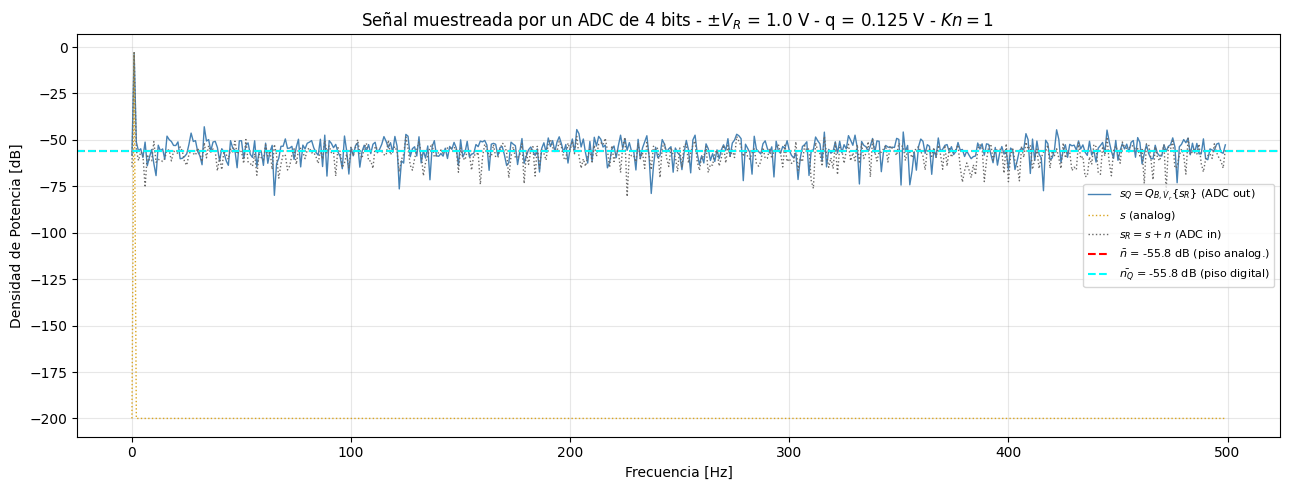

In [10]:
def calcular_psd_dB(señal, fm):
    N = len(señal)
    S = np.fft.fft(señal) / N
    freqs = np.fft.fftfreq(N, d=1/fm)[:N//2] #genero un vector de frecuencias, le paso la cantidad de muestras y el periodo de meustreo
    psd = (2 / fm) * (np.abs(S[:N//2])**2) * N #multiplico la densidad de potencia por 2 por la parte negativa y divido por fm para que quede pot/Hz
    psd_dB = 10 * np.log10(psd + 1e-20)
    return freqs, psd_dB

freqs, psd_s   = calcular_psd_dB(s, fm)
freqs, psd_sR  = calcular_psd_dB(señal_con_ruido, fm)
freqs, psd_sQ  = calcular_psd_dB(xq, fm)

# Pisos de ruido
piso_analogico_dB = 10 * np.log10(2 * Pr_n / fm)
piso_digital_dB   = 10 * np.log10(2 * Pq   / fm)

# Gráfico
plt.figure(figsize=(13, 5))

plt.plot(freqs, psd_sQ, color='steelblue', lw=1,
         label=r'$s_Q = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(freqs, psd_s,  color='goldenrod', lw=1, linestyle='dotted',
         label=r'$s$ (analog)')
plt.plot(freqs, psd_sR, color='dimgray',   lw=1, linestyle='dotted',
         label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analogico_dB, color='red',  lw=1.5, linestyle='--',
            label=rf'$\bar{{n}}$ = {piso_analogico_dB:.1f} dB (piso analog.)')
plt.axhline(piso_digital_dB,   color='cyan', lw=1.5, linestyle='--',
            label=rf'$\bar{{n_Q}}$ = {piso_digital_dB:.1f} dB (piso digital)')

plt.title(rf'Señal muestreada por un ADC de {B} bits - $\pm V_R$ = {Vfs/2:.1f} V - q = {q:.3f} V - $Kn =1$ ')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

En las tres señales se observa un pico concentrado en fs = 1 Hz. Este pico representa prácticamente toda la potencia de la señal útil. Se da en -3dB, pues, $$\text{pico} \approx 10 \cdot \log_{10}\left(\frac{A^2/2}{\Delta f}\right) = 10 \cdot \log_{10}\left(\frac{0.5}{1}\right) = -3 \text{ dB}$$ teniendo en cuenta que la resolucion espectral es $\Delta f= {fm}/{N}$.Por fuera del pico, la potencia se distribuye formando un piso de ruido.Este piso es la densidad espectral del ruido. También se graficaron dos pisos de referencia, el piso analógico, correspondiente al ruido agregado antes de la cuantización ($Pn = Kn.Pq$), y el piso digital, correspondiente al ruido de cuantización ($Pq = \frac{q²}{12}$). Dado que en este caso $Kn = 1$, ambas potencias son iguales y los pisos coinciden.

Ahora analizo el histograma del error de cuantización, siendo este definido como $ \text{Error de cuantización} = \text{Señal Cuantizada} - \text{Señal con Ruido} $

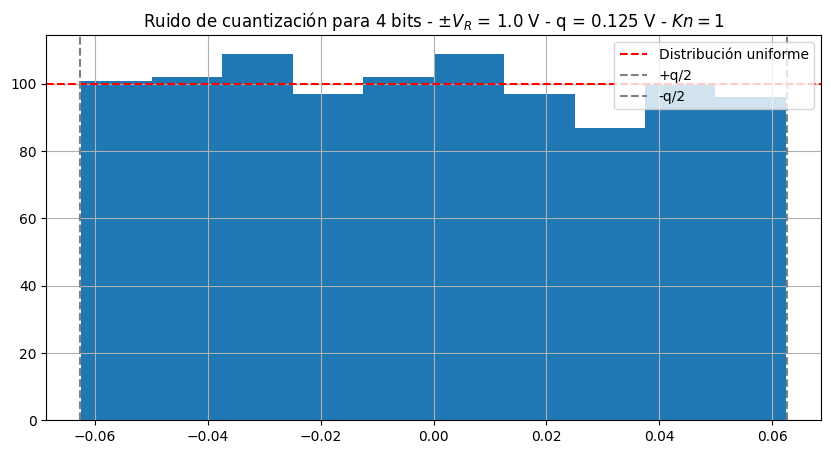

In [11]:
ee =   xq - señal_con_ruido #error de cuantizacion


altura_teorica = len(ee) / (q / (q/10))  # N muestras / 10 bins en rango q

plt.figure(figsize=(10, 5))
plt.hist(ee, bins=10)
plt.axhline(len(ee)/10, color='red', linestyle='--', label='Distribución uniforme')
plt.axvline( q/2, color='gray', linestyle='--', label='+q/2')
plt.axvline(-q/2, color='gray', linestyle='--', label='-q/2')
plt.title(rf'Ruido de cuantización para {B} bits - $\pm V_R$ = {Vfs/2:.1f} V - q = {q:.3f} V - $Kn = 1$')
plt.legend()
plt.grid()

Como se observa gráficamente en el histograma, el error de cuantización se distribuye de forma aproximadamente uniforme en el intervalo $[-{q}/{2} , {q}/{2}]$

### Caso B = 4 bits y $Kn = 10$

Ahora, el enunciado nos pide analizar para una de las siguientes configuraciones $B = ̣\{4, 8 , 16\}$ bits, $kn=\{1/10,1,10\}$. Elijo y analizo el caso donde tenemos B = 4 bits y el factor de escala $Kn = 10$. La señal sin ruido no tendrá cambios.

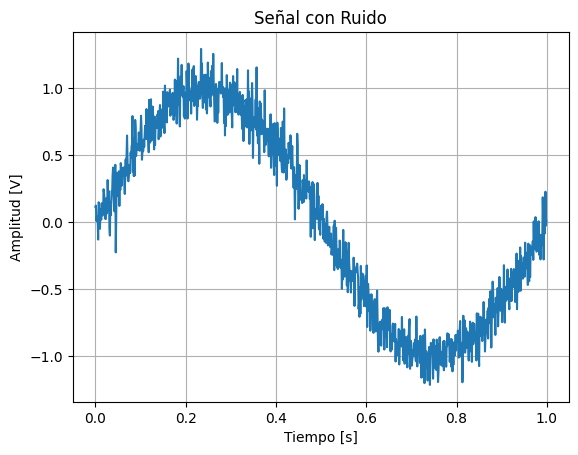

In [12]:
import numpy as np
import matplotlib.pyplot as plt


def mi_funcion_sen(vmax, dc, fs, ph, nn, fm):

    tt = np.arange(nn) / fm 
    s = dc + vmax * np.sin(2 * np.pi * fs * tt + ph)

    return tt, s

vmax = 1
dc = 0
ph = 0
nn = 1000
fm = 1000 
fs = fm/nn 
tt, s = mi_funcion_sen(vmax, dc, fs, ph, nn, fm)

#%% # Ruido y potencia

mu = 0
nn = 1000
vmax=1

B = 4
Vfs = 2 #+1 y -1 el rango es 2
q=Vfs/2**B
K_n = 10
Pq = (q**2)/12

Pr_n = K_n*Pq

sigma = np.sqrt(Pr_n) #es la que uso en ruido, sigma² es potencia de ruido

n = np.random.normal(mu, sigma, nn)

señal_con_ruido = s + n


plt.figure()
plt.plot(tt,señal_con_ruido, label = "señal con ruido")
plt.title(label = "Señal con Ruido")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.grid()

Observamos que al aumentar el factor de escala y manteniendo constante la cantidad de bits va a aumentar la potencia del ruido debido a que el ruido de cuantización se mantiene constante  $Pn (aumenta) = Kn(aumenta).Pq(constante)$

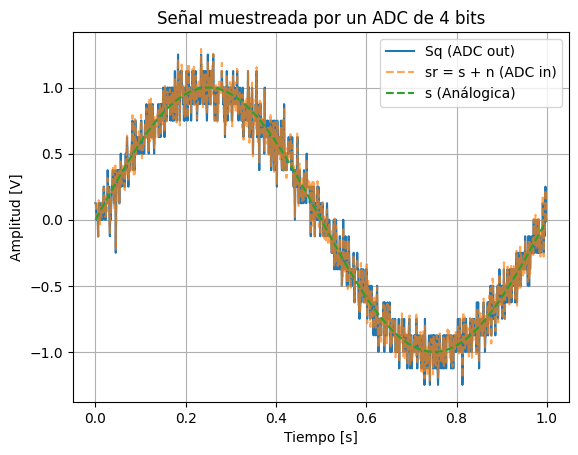

In [13]:
xq = np.round(señal_con_ruido / q)*q
# =========================
# Gráfico final
# =========================
plt.figure()

# ADC out (línea continua)
plt.plot(tt, xq, label='Sq (ADC out)')

# ADC in (solo puntos)
plt.plot(tt, señal_con_ruido, '--', markersize=3, alpha=0.7, label='sr = s + n (ADC in)')

# Señal analógica (línea punteada)
plt.plot(tt, s, '--', label='s (Análogica)')

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal muestreada por un ADC de 4 bits")
plt.legend()
plt.grid()

plt.show()

Al ser el ruido mucho mas grande la señal de entrada al ADC (señal con ruido) cuantiza valores mas erráticos, por lo que la salida cuantizada va a saltar más entre niveles.

Ahora analizamos la densidad espectral de potencias de las tres señales

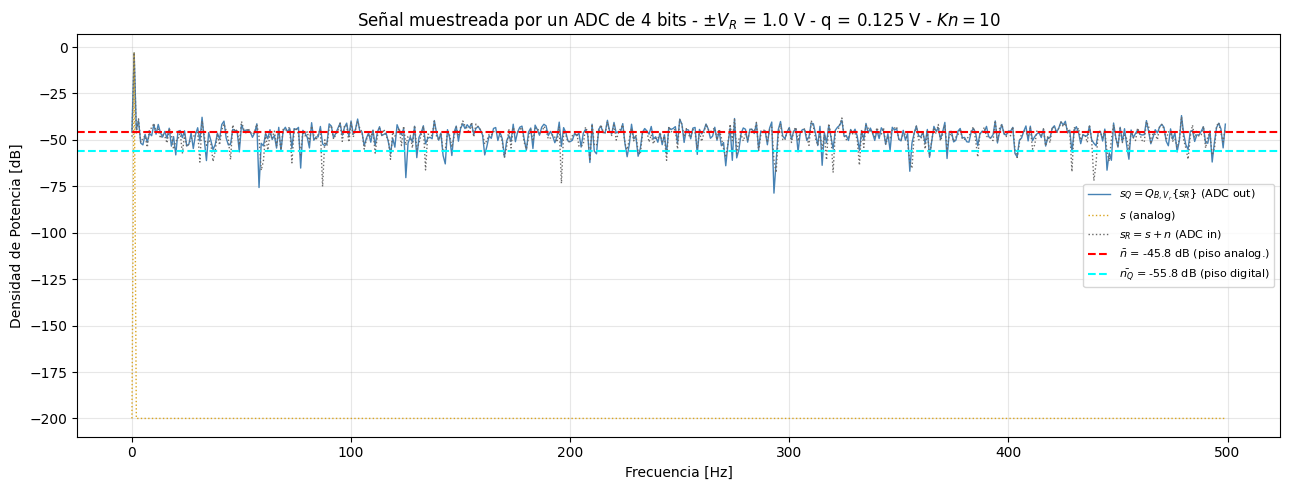

In [14]:

# =========================
# PSD - Densidad Espectral de Potencia
# =========================

def calcular_psd_dB(señal, fm):
    N = len(señal)
    S = np.fft.fft(señal) / N
    freqs = np.fft.fftfreq(N, d=1/fm)[:N//2] #genero un vector de frecuencias, le paso la cantidad de muestras y el periodo de meustreo
    psd = (2 / fm) * (np.abs(S[:N//2])**2) * N
    psd_dB = 10 * np.log10(psd + 1e-20)
    return freqs, psd_dB

freqs, psd_s   = calcular_psd_dB(s, fm)
freqs, psd_sR  = calcular_psd_dB(señal_con_ruido, fm)
freqs, psd_sQ  = calcular_psd_dB(xq, fm)

# Pisos de ruido
piso_analogico_dB = 10 * np.log10(2 * Pr_n / fm)
piso_digital_dB   = 10 * np.log10(2 * Pq   / fm)

# Gráfico
plt.figure(figsize=(13, 5))

plt.plot(freqs, psd_sQ, color='steelblue', lw=1,
         label=r'$s_Q = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(freqs, psd_s,  color='goldenrod', lw=1, linestyle='dotted',
         label=r'$s$ (analog)')
plt.plot(freqs, psd_sR, color='dimgray',   lw=1, linestyle='dotted',
         label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analogico_dB, color='red',  lw=1.5, linestyle='--',
            label=rf'$\bar{{n}}$ = {piso_analogico_dB:.1f} dB (piso analog.)')
plt.axhline(piso_digital_dB,   color='cyan', lw=1.5, linestyle='--',
            label=rf'$\bar{{n_Q}}$ = {piso_digital_dB:.1f} dB (piso digital)')

plt.title(rf'Señal muestreada por un ADC de {B} bits - $\pm V_R$ = {Vfs/2:.1f} V - q = {q:.3f} V - $Kn = 10$')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Al aumentar el $Kn = 10$, la potencia del ruido analógico se incrementa diez veces respecto al ruido de cuantización. Como la densidad espectral de potencia se expresa en escala logarítmica, esto se traduce en un aumento de 10 dB en el piso de ruido analógico respecto al piso de ruido de cuantización (digital). Por lo tanto, ambos pisos dejan de coincidir como en el caso anterior de $Kn =1$.

Ahora analizamos el histograma del error de cuantización para este caso

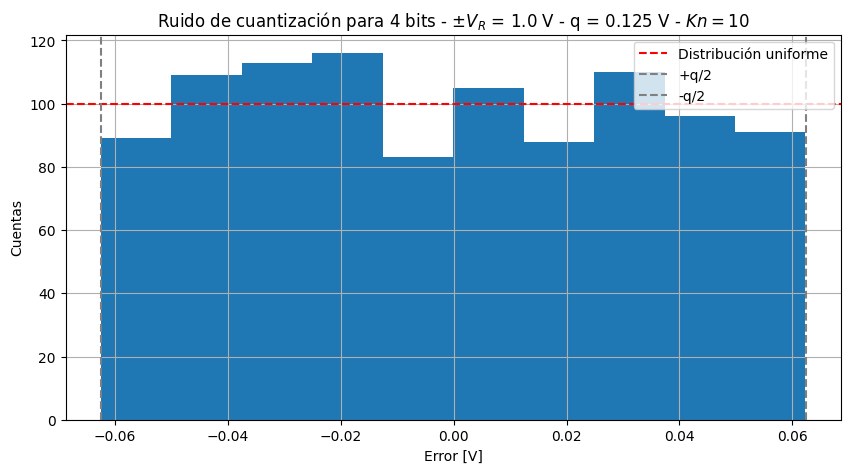

In [15]:
ee =   xq - señal_con_ruido #error de cuantizacion


altura_teorica = len(ee) / (q / (q/10))  # N muestras / 10 bins en rango q

plt.figure(figsize=(10, 5))
plt.hist(ee, bins=10)
plt.axhline(len(ee)/10, color='red', linestyle='--', label='Distribución uniforme')
plt.axvline( q/2, color='gray', linestyle='--', label='+q/2')
plt.axvline(-q/2, color='gray', linestyle='--', label='-q/2')
plt.title(rf'Ruido de cuantización para {B} bits - $\pm V_R$ = {Vfs/2:.1f} V - q = {q:.3f} V - $Kn = 10$')
plt.xlabel('Error [V]')
plt.ylabel('Cuentas')
plt.legend()
plt.grid()

En este caso, la distribución del error de cuantización también tiende a ser uniforme en el intervalo $[-{q}/{2} , {q}/{2}]$. Sin embargo, al aumentar $Kn$ se incrementa la potencia del ruido en la entrada del ADC, lo que provoca que la señal se vuelva menos correlacionada con el error de cuantización. Como consecuencia, la distribución del error se aproxima mejor a una distribución uniforme en comparación con el caso $Kn=1$.

### Caso B = 8 bits y $Kn = 10$

Ahora elijo y analizo el caso donde tenemos B = 8 bits y el factor de escala $Kn = 10$. La señal sin ruido no tendrá cambios.

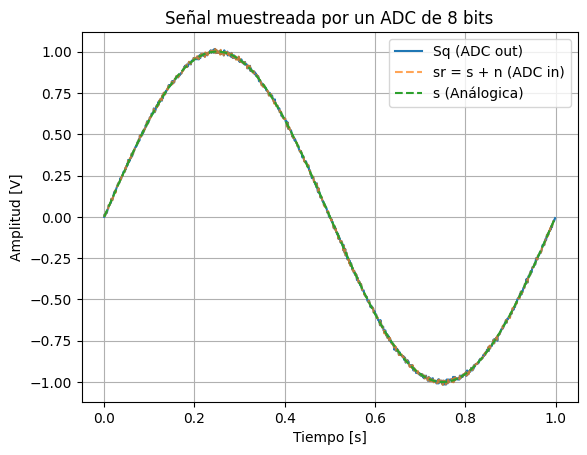

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def mi_funcion_sen(vmax, dc, fs, ph, nn, fm):

    tt = np.arange(nn) / fm 
    s = dc + vmax * np.sin(2 * np.pi * fs * tt + ph)

    return tt, s

vmax = 1
dc = 0
ph = 0
nn = 1000
fm = 1000 
fs = fm/nn 
tt, s = mi_funcion_sen(vmax, dc, fs, ph, nn, fm)

#%% # Ruido y potencia

mu = 0
nn = 1000
vmax=1

B = 8
Vfs = 2 #+1 y -1 el rango es 2
q=Vfs/2**B
K_n = 10
Pq = (q**2)/12

Pr_n = K_n*Pq

sigma = np.sqrt(Pr_n) #es la que uso en ruido, sigma² es potencia de ruido

n = np.random.normal(mu, sigma, nn)

señal_con_ruido = s + n

xq = np.round(señal_con_ruido / q)*q
# =========================
# Gráfico final
# =========================
plt.figure()

# ADC out (línea continua)
plt.plot(tt, xq, label='Sq (ADC out)')

# ADC in (solo puntos)
plt.plot(tt, señal_con_ruido, '--', markersize=3, alpha=0.7, label='sr = s + n (ADC in)')

# Señal analógica (línea punteada)
plt.plot(tt, s, '--', label='s (Análogica)')

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal muestreada por un ADC de 8 bits")
plt.legend()
plt.grid()

plt.show()


Observamos que aumentar la cantidad de bits mejora la calidad de la señal cuantizada. Esto se debe a que al aumentar la cantidad de bits estamos disminuyendo el paso de cuantización $ q = \frac{Vf}{2^B}$

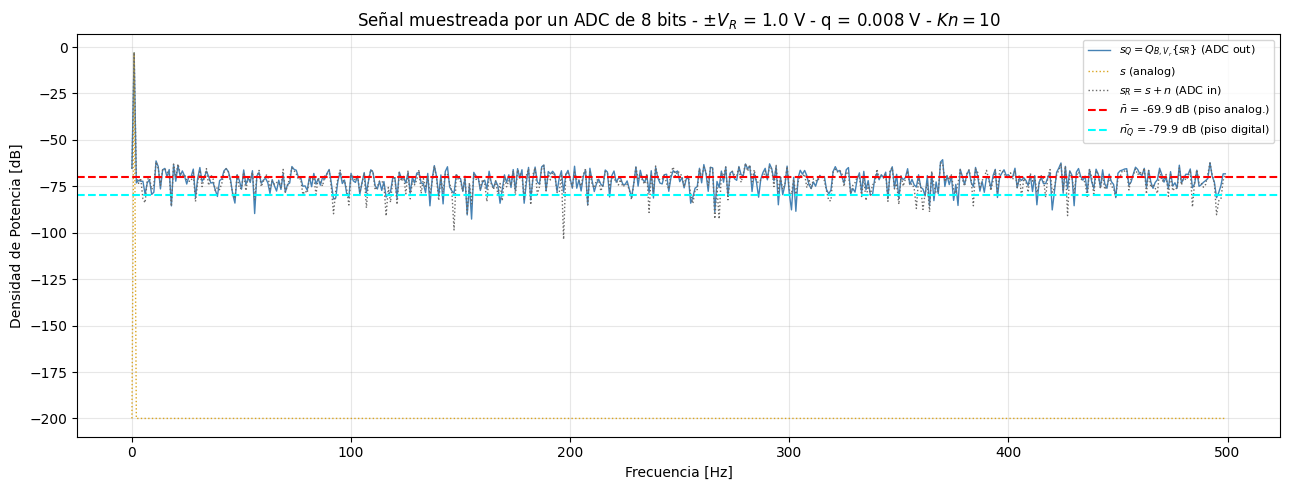

In [17]:
# =========================
# PSD - Densidad Espectral de Potencia
# =========================

def calcular_psd_dB(señal, fm):
    N = len(señal)
    S = np.fft.fft(señal) / N
    freqs = np.fft.fftfreq(N, d=1/fm)[:N//2] #genero un vector de frecuencias, le paso la cantidad de muestras y el periodo de meustreo
    psd = (2 / fm) * (np.abs(S[:N//2])**2) * N
    psd_dB = 10 * np.log10(psd + 1e-20)
    return freqs, psd_dB

freqs, psd_s   = calcular_psd_dB(s, fm)
freqs, psd_sR  = calcular_psd_dB(señal_con_ruido, fm)
freqs, psd_sQ  = calcular_psd_dB(xq, fm)

# Pisos de ruido
piso_analogico_dB = 10 * np.log10(2 * Pr_n / fm)
piso_digital_dB   = 10 * np.log10(2 * Pq   / fm)

# Gráfico
plt.figure(figsize=(13, 5))

plt.plot(freqs, psd_sQ, color='steelblue', lw=1,
         label=r'$s_Q = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(freqs, psd_s,  color='goldenrod', lw=1, linestyle='dotted',
         label=r'$s$ (analog)')
plt.plot(freqs, psd_sR, color='dimgray',   lw=1, linestyle='dotted',
         label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analogico_dB, color='red',  lw=1.5, linestyle='--',
            label=rf'$\bar{{n}}$ = {piso_analogico_dB:.1f} dB (piso analog.)')
plt.axhline(piso_digital_dB,   color='cyan', lw=1.5, linestyle='--',
            label=rf'$\bar{{n_Q}}$ = {piso_digital_dB:.1f} dB (piso digital)')

plt.title(rf'Señal muestreada por un ADC de {B} bits - $\pm V_R$ = {Vfs/2:.1f} V - q = {q:.3f} V - $Kn = 10$')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Vemos que la densidad espectral de potencia de la señal es esperable, donde el piso de ruido analogico esta por encima del piso de ruido digital. Esto se debe al factor de potencia Kn = 10, que nos indica que la potencia de ruido analogico sera 10 veces mas grande que la potencia de ruido digital. Si el factor de potencia seria Kn = 1 lo que sucedería es que los pisos digital y analógico estarían en el mismo nivel.

### Caso B = 16 bits y $Kn = 1/10$

Ahora elijo y analizo el caso donde tenemos B = 16 bits y el factor de escala $Kn = 1/10$. La señal sin ruido no tendrá cambios.

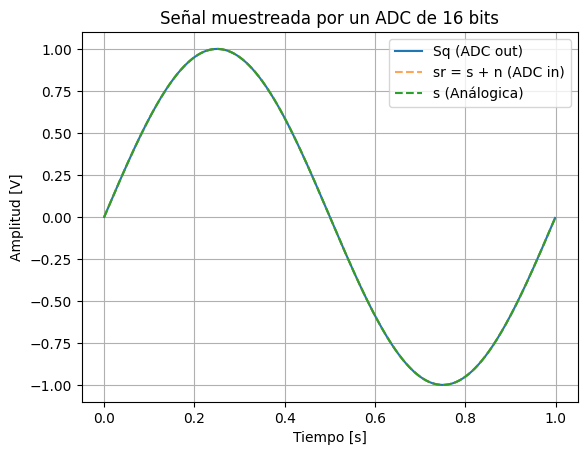

In [18]:
import numpy as np
import matplotlib.pyplot as plt


def mi_funcion_sen(vmax, dc, fs, ph, nn, fm):

    tt = np.arange(nn) / fm 
    s = dc + vmax * np.sin(2 * np.pi * fs * tt + ph)

    return tt, s

vmax = 1
dc = 0
ph = 0
nn = 1000
fm = 1000 
fs = fm/nn 
tt, s = mi_funcion_sen(vmax, dc, fs, ph, nn, fm)

#%% # Ruido y potencia

mu = 0
nn = 1000
vmax=1

B = 16
Vfs = 2 #+1 y -1 el rango es 2
q=Vfs/2**B
K_n = 1/10
Pq = (q**2)/12

Pr_n = K_n*Pq

sigma = np.sqrt(Pr_n) #es la que uso en ruido, sigma² es potencia de ruido

n = np.random.normal(mu, sigma, nn)

señal_con_ruido = s + n

xq = np.round(señal_con_ruido / q)*q
# =========================
# Gráfico final
# =========================
plt.figure()

# ADC out (línea continua)
plt.plot(tt, xq, label='Sq (ADC out)')

# ADC in (solo puntos)
plt.plot(tt, señal_con_ruido, '--', markersize=3, alpha=0.7, label='sr = s + n (ADC in)')

# Señal analógica (línea punteada)
plt.plot(tt, s, '--', label='s (Análogica)')

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal muestreada por un ADC de 16 bits")
plt.legend()
plt.grid()

plt.show()


Observamos en este caso que aumentar la cantidad de bits a B = 16 mejoró la calidad de la señal cuantizada y es indistinguible con respecto a la señal senoidal sin ruido agregado.

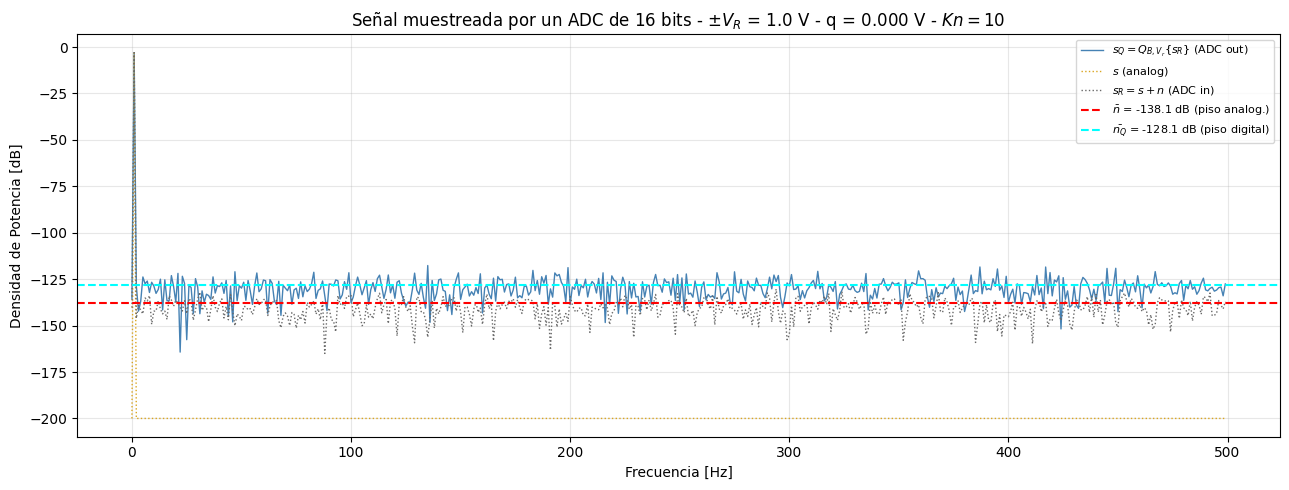

In [19]:
# =========================
# PSD - Densidad Espectral de Potencia
# =========================

def calcular_psd_dB(señal, fm):
    N = len(señal)
    S = np.fft.fft(señal) / N
    freqs = np.fft.fftfreq(N, d=1/fm)[:N//2] #genero un vector de frecuencias, le paso la cantidad de muestras y el periodo de meustreo
    psd = (2 / fm) * (np.abs(S[:N//2])**2) * N
    psd_dB = 10 * np.log10(psd + 1e-20)
    return freqs, psd_dB

freqs, psd_s   = calcular_psd_dB(s, fm)
freqs, psd_sR  = calcular_psd_dB(señal_con_ruido, fm)
freqs, psd_sQ  = calcular_psd_dB(xq, fm)

# Pisos de ruido
piso_analogico_dB = 10 * np.log10(2 * Pr_n / fm)
piso_digital_dB   = 10 * np.log10(2 * Pq   / fm)

# Gráfico
plt.figure(figsize=(13, 5))

plt.plot(freqs, psd_sQ, color='steelblue', lw=1,
         label=r'$s_Q = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(freqs, psd_s,  color='goldenrod', lw=1, linestyle='dotted',
         label=r'$s$ (analog)')
plt.plot(freqs, psd_sR, color='dimgray',   lw=1, linestyle='dotted',
         label=r'$s_R = s + n$ (ADC in)')

plt.axhline(piso_analogico_dB, color='red',  lw=1.5, linestyle='--',
            label=rf'$\bar{{n}}$ = {piso_analogico_dB:.1f} dB (piso analog.)')
plt.axhline(piso_digital_dB,   color='cyan', lw=1.5, linestyle='--',
            label=rf'$\bar{{n_Q}}$ = {piso_digital_dB:.1f} dB (piso digital)')

plt.title(rf'Señal muestreada por un ADC de {B} bits - $\pm V_R$ = {Vfs/2:.1f} V - q = {q:.3f} V - $Kn = 10$')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Vemos que la densidad espectral de potencia de la señal también es esperable en este caso, pues el piso de ruido analogico esta por debajo del piso de ruido digital. Esto se debe al factor de potencia $Kn = 1/10$, que nos indica que la potencia de ruido analogico será 10 veces menor que la potencia de ruido digital. Si el factor de potencia seria $Kn = 1$ lo que sucedería es que los pisos digital y analógico estarían en el mismo nivel.

Como conclusión, se observó que aumentar la cantidad de bits reduce el paso de cuantización $q$, generando una señal digitalizada más parecida a la señal analógica original. Analizando la densidad espectral de potencia, se identificaron dos casos:

* Cuando domina el piso de ruido de cuantización (ruido digital) significa que el ADC tiene pocos bits, el paso de cuantización es grande y está generando un ruido de cuantizacíon, por lo que tendría sentido aumentar la cantidad de bits.
* Cuando domina el ruido analógico, el piso digital está por debajo del nivel de ruido de la señal de entrada, el paso de cuantizacíon es mas chico por lo que estaríamos desperdiciando bits para muestrear ruido.

## Bonus

### Relacion SNR y cantidad de bits del ADC

Lo que nos describe el Holton en el capitulo 6.7 "ADC Quantization" es que una buena forma de cuantificar el efecto de la reduccion de ruido mediante el convertidor A/D de sobremuestreo es expresar el aumento de la relacion señal/ruido (SNR) en terminos de un aumento en el número efectivo de bits (ENOB) del convertidor.
$$\frac{\sigma_e^2}{D} = \frac{\Delta V^2}{12D} = \frac{2^{-2N}V_{FS}^2}{12 \cdot 2^B} = \frac{2^{-(2N+B)}V_{FS}^2}{12}$$

$$\text{SNR} = 10\log_{10}\frac{12\sigma_x^2}{2^{-(2N+B)}V_{FS}^2} = 6.02(N + 0.5B) + 10.79 + 20\log_{10}\left(\frac{\sigma_x}{V_{FS}}\right)$$

Como $$\sigma_x = \frac{V_{FS}/2}{\sqrt{2}} = \frac{V_{FS}}{2\sqrt{2}}$$

Nos queda $$20\log_{10}\left(\frac{\sigma_x}{V_{FS}}\right) = 20\log_{10}\left(\frac{1}{2\sqrt{2}}\right) \approx -9.03 \text{ dB}$$

FInalmente obtenemos la expresión $$\boxed{\text{SNR} = 6.02N + 1.76 \text{ dB}}$$

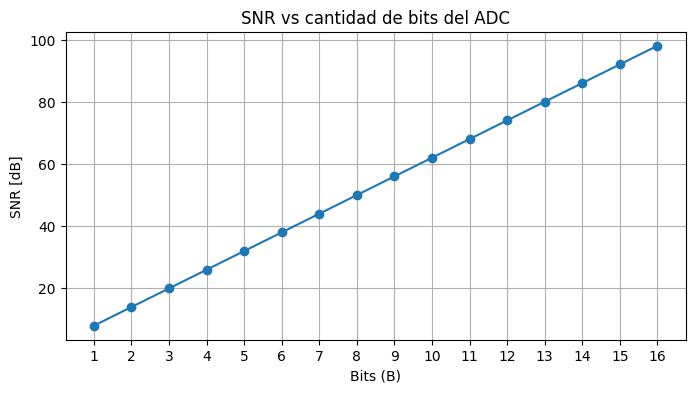

In [20]:
bits = np.arange(1, 17)
snr  = 6.02 * bits + 1.76

plt.figure(figsize=(8, 4))
plt.plot(bits, snr, 'o-')
plt.xlabel('Bits (B)')
plt.ylabel('SNR [dB]')
plt.title('SNR vs cantidad de bits del ADC')
plt.grid()
plt.xticks(bits)
plt.show()

Donde observamos en el gráfico que a medida que aumenta el numero de bits también aumenta el SNR

## Efecto aliasing

Cuando la frecuencia de muestreo $f_m$ no cumple el criterio de Nyquist, es decir, cuando:

$$f_m <  2\cdot f_{señal}$$

se produce el fenómeno de alisaing. En este caso, la señal muestreada se pliega en frecuencia, generandi componentes espectrales que no corresponden a la señal original. Como consecuencia, se observa una señal con una frecuencia aparente dada por:

$$f_{alias} = |f_{señal} - k\cdot f_m|$$

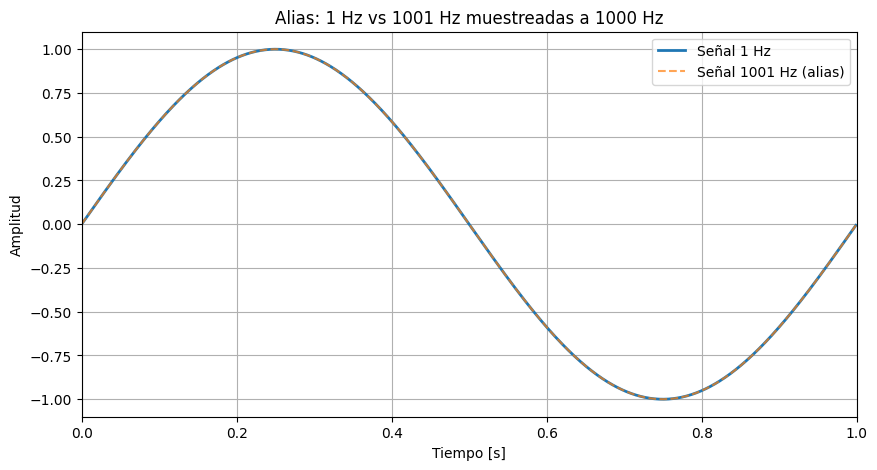

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
fm = 1000
nn = 1000
tt = np.arange(nn) / fm

# Señales
fs1 = 1      # señal real baja frecuencia
fs2 = 1001    # señal alta que genera alias

s1 = np.sin(2 * np.pi * fs1 * tt)
s2 = np.sin(2 * np.pi * fs2 * tt)

# Gráfico
plt.figure(figsize=(10,5))

plt.plot(tt, s1, label='Señal 1 Hz', linewidth=2)
plt.plot(tt, s2, '--', label='Señal 1001 Hz (alias)', alpha=0.7)

plt.xlim(0, 1)  # ver un par de períodos
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Alias: 1 Hz vs 1001 Hz muestreadas a 1000 Hz")
plt.legend()
plt.grid()

plt.show()

Se observa que una señal de 1001 Hz muestreada a 1000 Hz resulta indistinguible de una señal de 1 Hz, ya que ambas generan exactamente las mismas muestras. Esto evidencia que, debido al aliasing, diferentes frecuencias continuas pueden ser indistinguibles en el dominio discreto. Este fenómeno demuestra que el muestreo introduce una periodicidad en el dominio de la frecuencia